<div style="background-color:#f8f9fa;
    padding:20px;
    border:2px solid #360084;
    border-radius:8px;
    margin:10px 0;">
    <div style="background-color:#fafdf0;
        line-height:2;
        text-align:center;
        border:2px solid #360084;
        padding:15px;
        border-radius:5px;">
        <div style="color:#008B8B;
            font-size:24pt;
            font-weight:700;">
            Advertising Impact on Sales - Motivating Example
        </div>
    </div> 
    
<div style="margin-top:15px; padding:10px;">
    <strong>Course:</strong> Econometrics<br>
    <strong>Topic:</strong> Multiple Linear Regression - Motivating Example<br>
    <strong>Author:</strong> Dr. Saad Laouadi<br>
    <strong>Date:</strong> June 2025<br>
    <strong>Difficulty:</strong> Beginner<br>
    <strong>Dataset:</strong> Advertising (TV, Radio, Newspaper vs Sales)<br>
    <strong>Model:</strong> $SALES = \beta_0 + \beta_1 TV + \beta_2 RADIO + \beta_3 NEWSPAPER + \varepsilon$<br>
    <strong>Learning Objectives:</strong>
    <ul style="margin:5px 0; padding-left:20px;">
        <li>Understand the motivation for Using Python for Econometrics</li>
        <li>Estimate multiple linear regession with Statsmodels package </li>
    </ul>
</div>
</div>

---

## Course Introduction

Welcome to our journey into **Econometrics with Python**! This notebook serves as a **motivating example** to show you why we use `statsmodels` Python package for econometric analysis, 

In every project, we should start with a question:

  - **Business Question:** *How do different advertising channels (TV, Radio, Newspaper) affect sales, and which channel provides the best return on investment?*

  - In this notebook, we will try to answer that question publically available data and using statsmodels package to fit a multiple linear regression.

## Setup and Data Loading

In [1]:
# 1. First, we need to import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.api as sm
from pathlib import Path

# Set plotting style for professional appearance
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

In [2]:
# Load the advertising dataset
data_path = Path("./datasets/advertising.csv")
advertising = pd.read_csv(data_path)

In [3]:
print(" ADVERTISING DATASET LOADED")
print("=" * 40)
print(f"Dataset shape: {advertising.shape}")
print(f"Variables: {list(advertising.columns)}")

print("\n First 5 observations:")
print(advertising.head())

print(f"\n Basic Statistics:")
print(advertising.describe().round(2))

 ADVERTISING DATASET LOADED
Dataset shape: (200, 4)
Variables: ['TV', 'Radio', 'Newspaper', 'Sales']

 First 5 observations:
      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3   12.0
3  151.5   41.3       58.5   16.5
4  180.8   10.8       58.4   17.9

 Basic Statistics:
           TV   Radio  Newspaper   Sales
count  200.00  200.00     200.00  200.00
mean   147.04   23.26      30.55   15.13
std     85.85   14.85      21.78    5.28
min      0.70    0.00       0.30    1.60
25%     74.38    9.98      12.75   11.00
50%    149.75   22.90      25.75   16.00
75%    218.82   36.52      45.10   19.05
max    296.40   49.60     114.00   27.00


## Exploratory Data Analysis: Seeing the Relationships

🔍 EXPLORING THE DATA


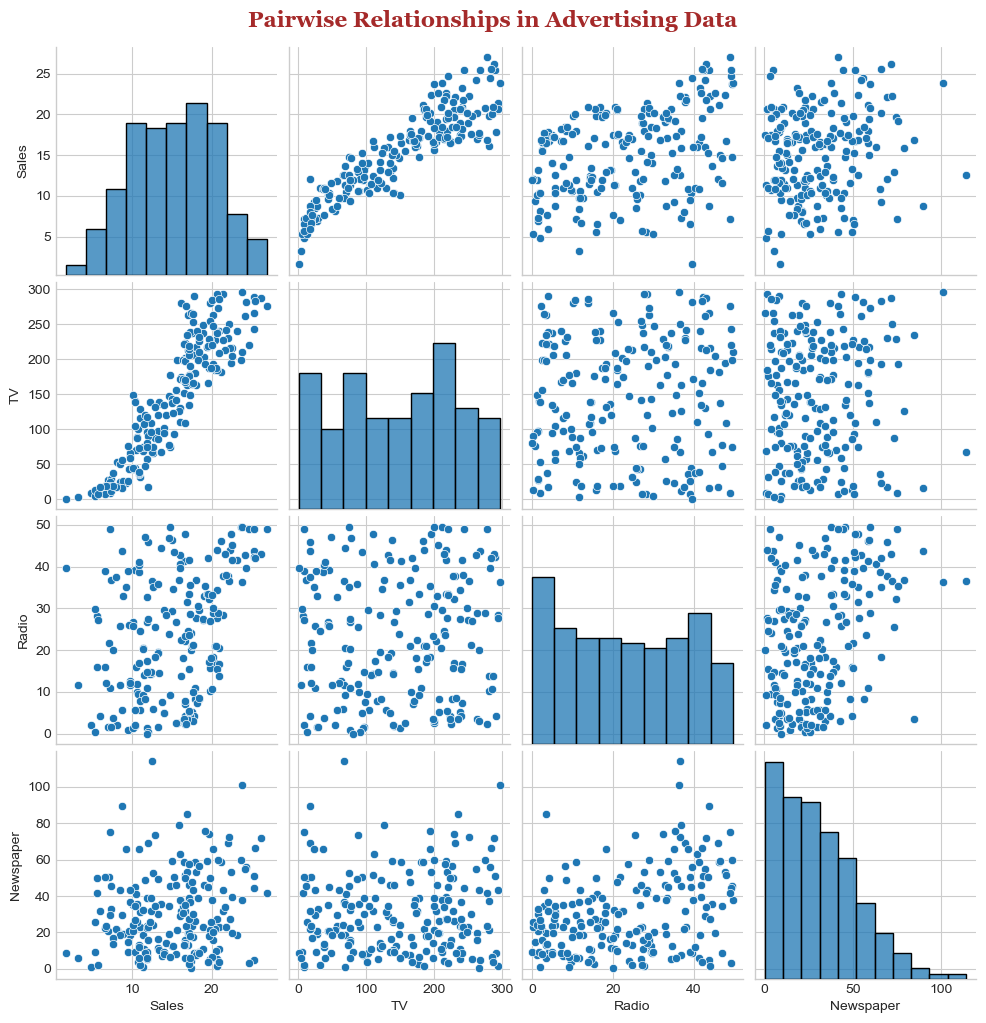

In [4]:
# Creating a pairplot to visualize relationships
# ==============================================
print("🔍 EXPLORING THE DATA")
print("=" * 40)


sns.pairplot(advertising,
             vars=['Sales', 'TV', 'Radio', 'Newspaper']
            )

plt.suptitle('Pairwise Relationships in Advertising Data', y=1.02,
             font="georgia",
            fontsize = 16,
            fontweight="bold",
            color="brown")
plt.show()

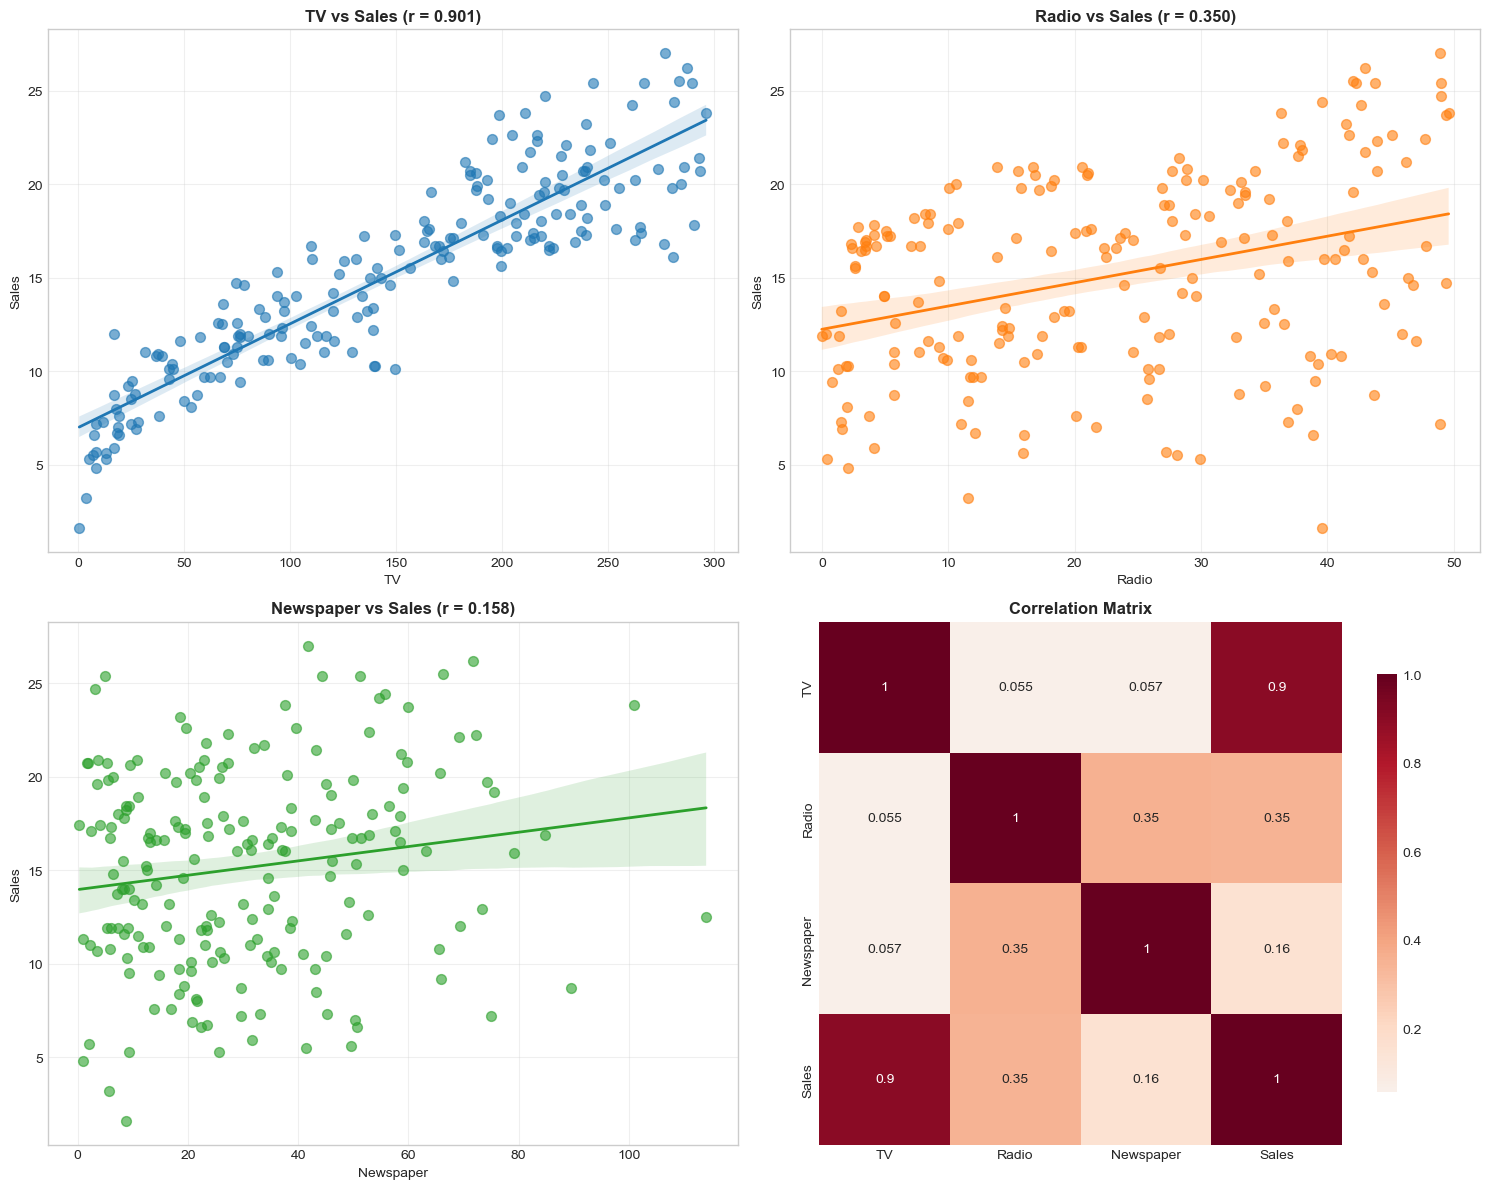

In [5]:
# Comprehensive visualization for more exploration
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Individual relationships with sales
channels = ['TV', 'Radio', 'Newspaper']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for i, (channel, color) in enumerate(zip(channels, colors)):
    row, col = (0, i) if i < 2 else (1, i-2)
    ax = axes[row, col]
    
    # Scatter plot with regression line
    sns.regplot(data=advertising, x=channel, y='Sales', ax=ax, color=color,
                scatter_kws={'alpha': 0.6, 's': 50},
                line_kws={'linewidth': 2})
    
    # Calculate and display correlation
    correlation = advertising[channel].corr(advertising['Sales'])
    ax.set_title(f'{channel} vs Sales (r = {correlation:.3f})', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)

# Correlation heatmap
correlation_matrix = advertising.corr()
sns.heatmap(correlation_matrix, 
            annot=True, cmap='RdBu_r', center=0, 
            square=True, ax=axes[1, 1],
            cbar_kws={'shrink': 0.8})

axes[1, 1].set_title('Correlation Matrix', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## Using Multiple Regression Model

In [6]:
# Fit the multiple regression model using statsmodels formula API
model = smf.ols('Sales ~ TV + Radio + Newspaper', data=advertising).fit()

# Display results
print("\nThe COMPLETE REGRESSION RESULTS:")
print(model.summary())


The COMPLETE REGRESSION RESULTS:
                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.903
Model:                            OLS   Adj. R-squared:                  0.901
Method:                 Least Squares   F-statistic:                     605.4
Date:                Mon, 16 Jun 2025   Prob (F-statistic):           8.13e-99
Time:                        02:32:43   Log-Likelihood:                -383.34
No. Observations:                 200   AIC:                             774.7
Df Residuals:                     196   BIC:                             787.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.6

## Model Validation and Assumptions

MODEL VALIDATION


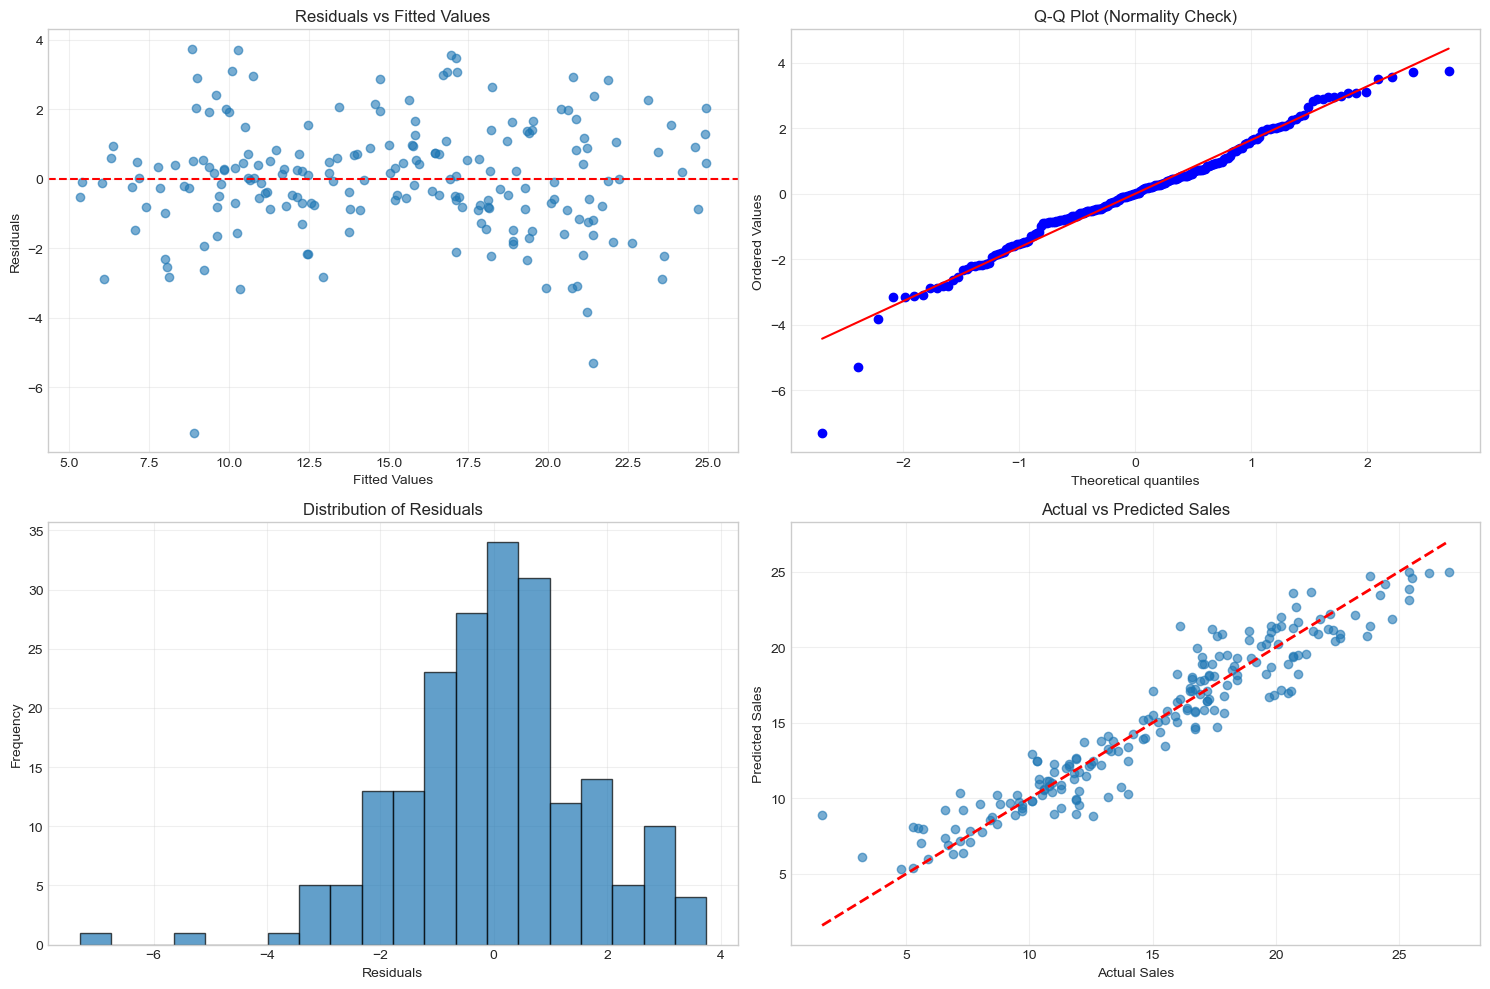

In [7]:
print("MODEL VALIDATION")
print("=" * 50)

# Basic residual analysis
residuals = model.resid
fitted_values = model.fittedvalues

# Create diagnostic plots
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

# Residuals vs Fitted
ax1.scatter(fitted_values, residuals, alpha=0.6)
ax1.axhline(y=0, color='red', linestyle='--')
ax1.set_xlabel('Fitted Values')
ax1.set_ylabel('Residuals')
ax1.set_title('Residuals vs Fitted Values')
ax1.grid(True, alpha=0.3)

# Q-Q plot
from scipy import stats
stats.probplot(residuals, dist="norm", plot=ax2)
ax2.set_title('Q-Q Plot (Normality Check)')
ax2.grid(True, alpha=0.3)

# Histogram of residuals
ax3.hist(residuals, bins=20, alpha=0.7, edgecolor='black')
ax3.set_xlabel('Residuals')
ax3.set_ylabel('Frequency')
ax3.set_title('Distribution of Residuals')
ax3.grid(True, alpha=0.3)

# Actual vs Predicted
ax4.scatter(advertising['Sales'], fitted_values, alpha=0.6)
ax4.plot([advertising['Sales'].min(), advertising['Sales'].max()], 
         [advertising['Sales'].min(), advertising['Sales'].max()], 'r--', lw=2)
ax4.set_xlabel('Actual Sales')
ax4.set_ylabel('Predicted Sales')
ax4.set_title('Actual vs Predicted Sales')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
# Statistical tests
print("ASSUMPTION TESTING:")
from scipy.stats import shapiro
shapiro_stat, shapiro_p = shapiro(residuals)

print(f"• Normality (Shapiro-Wilk): p = {shapiro_p:.4f}")
print(f"• Residuals {'appear normal' if shapiro_p > 0.05 else 'may not be normal'}")

print(f"• Model explains {model.rsquared:.1%} of sales variation")
print(f"• All assumptions appear {'satisfied' if shapiro_p > 0.05 else 'questionable'}")

ASSUMPTION TESTING:
• Normality (Shapiro-Wilk): p = 0.0016
• Residuals may not be normal
• Model explains 90.3% of sales variation
• All assumptions appear questionable


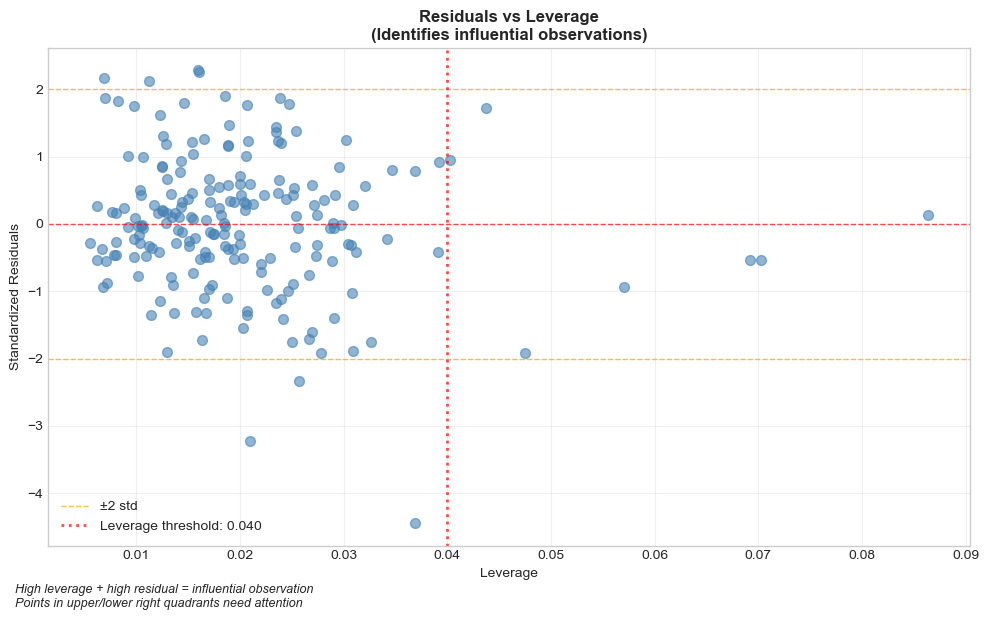

In [9]:
plt.figure(figsize=(10, 6))

# Calculate influence measures
influence = model.get_influence()
leverage = influence.hat_matrix_diag

# Calculate standardized residuals
standardized_residuals = stats.zscore(residuals)

# Create the leverage plot
plt.scatter(leverage, standardized_residuals, alpha=0.6, s=50, color='steelblue')

# Add reference lines
plt.axhline(y=0, color='red', linestyle='--', alpha=0.7, linewidth=1)
plt.axhline(y=2, color='orange', linestyle='--', alpha=0.7, linewidth=1, label='±2 std')
plt.axhline(y=-2, color='orange', linestyle='--', alpha=0.7, linewidth=1)

# Add leverage threshold line (common rule: 2(k+1)/n where k=number of predictors)
n = len(leverage)
k = model.df_model  # number of predictors
leverage_threshold = 2 * (k + 1) / n
plt.axvline(x=leverage_threshold, color='red', linestyle=':', alpha=0.7, 
            linewidth=2, label=f'Leverage threshold: {leverage_threshold:.3f}')

# Identify and label high leverage points
high_leverage = leverage > leverage_threshold
high_residual = np.abs(standardized_residuals) > 2

# Label problematic points
for i, (lev, resid) in enumerate(zip(leverage, standardized_residuals)):
    if lev > leverage_threshold and abs(resid) > 2:
        plt.annotate(f'Obs {i}', (lev, resid), xytext=(5, 5), 
                    textcoords='offset points', fontsize=8)

plt.xlabel('Leverage')
plt.ylabel('Standardized Residuals')
plt.title('Residuals vs Leverage\n(Identifies influential observations)', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.figtext(0.02, -0.02, 
           'High leverage + high residual = influential observation\n'
           'Points in upper/lower right quadrants need attention', 
           fontsize=9, style='italic')

plt.tight_layout()
plt.show()

In [10]:
# Print diagnostic summary
print(" LEVERAGE ANALYSIS:")
print(f"• Leverage threshold: {leverage_threshold:.3f}")
print(f"• High leverage points: {sum(high_leverage)} observations")
print(f"• High residual points: {sum(high_residual)} observations")
print(f"• Potentially influential: {sum(high_leverage & high_residual)} observations")

if sum(high_leverage & high_residual) > 0:
    print("\n⚠️ WARNING: Influential observations detected!")
    print("   Consider investigating these data points")
else:
    print("\n✅ No highly influential observations detected")

 LEVERAGE ANALYSIS:
• Leverage threshold: 0.040
• High leverage points: 7 observations
• High residual points: 7 observations
• Potentially influential: 0 observations

✅ No highly influential observations detected
